In [1]:
import importlib
import importlib.machinery
import io
import os
import sys
import types
import uuid
from datetime import datetime
from pathlib import Path

import cv2
import duckdb
import faiss
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import polars as pl
import requests
import torch
from PIL import Image
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoProcessor,
    CLIPModel,
    CLIPProcessor,
)
from ultralytics import YOLO

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

c:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef\bachproef26\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
MODEL_PATH = r"C:\Users\krist\runs\detect\yolo11s_SKU110K5\weights\best.pt"
# MODEL_PATH = r"C:\Users\krist\runs\detect\train6" # yolov8n

IMAGE_PATH = (
    r"C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef"
    r"\bachproef26\latex-hogent-bachproef\bachproef\datasets"
    r"\SKU-110K_fixed\images\test_16.jpg"
)

PARQUET_PATH = (
    r"C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef"
    r"\bachproef26\latex-hogent-bachproef\bachproef\datasets\food_images_long.parquet"
)

CROPS_ROOT   = "./crops"
INDEX_CACHE = r"C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef\bachproef26\latex-hogent-bachproef\bachproef\faiss_index2.bin"
META_CACHE  = r"C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef\bachproef26\latex-hogent-bachproef\bachproef\datasets\faiss_meta2.parquet"

# INDEX_CACHE = r"...\datasets\faiss_index_1536.bin"
# META_CACHE  = r"...\datasets\faiss_meta_1536.parquet"

CLIP_WEIGHT = 0.50  
OCR_WEIGHT = 0.40
VIS_WEIGHT = 0.10   

CONF         = 0.25  
TOP_K        = 5    

print("Variabelen ingeladen")

Variabelen ingeladen


In [3]:
#Florence-2
flash_attn = types.ModuleType("flash_attn")
flash_attn.__spec__ = importlib.machinery.ModuleSpec("flash_attn", None)
flash_attn_interface = types.ModuleType("flash_attn.flash_attn_interface")
flash_attn_interface.__spec__ = importlib.machinery.ModuleSpec("flash_attn.flash_attn_interface", None)
sys.modules["flash_attn"] = flash_attn
sys.modules["flash_attn.flash_attn_interface"] = flash_attn_interface
os.environ["FLASH_ATTENTION_FORCE_DISABLED"] = "1"

fl2_model_id  = "microsoft/Florence-2-base"
fl2_processor = AutoProcessor.from_pretrained(fl2_model_id, trust_remote_code=True)
fl2_model     = AutoModelForCausalLM.from_pretrained(
    fl2_model_id, trust_remote_code=True, attn_implementation="eager"
).to(device)
fl2_model.eval()
print("Florence-2 loaded")

# CLIP
FINETUNED_PATH = r".\clip\clip_finetuned"
clip_model     = CLIPModel.from_pretrained(FINETUNED_PATH).to(device)
clip_processor = CLIPProcessor.from_pretrained(FINETUNED_PATH)
clip_model.eval()
print("CLIP loaded")

#YOLO
yolo = YOLO(MODEL_PATH)
print("YOLO loaded")

Florence-2 loaded
CLIP loaded
YOLO loaded


In [4]:
@torch.no_grad()
def clip_embed(pil_image: Image.Image) -> np.ndarray:
    """Returns a normalised CLIP visual embedding (512-d)."""
    inputs = clip_processor(images=pil_image, return_tensors="pt").to(device)
    feats  = clip_model.get_image_features(**inputs)          # (1, 512)
    vec    = feats.squeeze().detach().cpu().float().numpy()
    return vec / (np.linalg.norm(vec) + 1e-9)


@torch.no_grad()
def fl2_embed(pil_image: Image.Image) -> np.ndarray:
    """Florence-2 visual embedding — uses _encode_image which is the correct internal API."""
    pixel_values = fl2_processor(images=pil_image, return_tensors="pt").pixel_values.to(device)
    
    visual_feats = fl2_model._encode_image(pixel_values)  # (1, num_tokens, lm_hidden)
    
    vec = visual_feats.mean(dim=1).squeeze().cpu().float().numpy()
    return vec / (np.linalg.norm(vec) + 1e-9)

@torch.no_grad()
def fl2_ocr_text(pil_image: Image.Image) -> str:
    """Run Florence-2 OCR and return the extracted text string."""
    inputs = fl2_processor(
        images=pil_image,
        text="<OCR>",
        return_tensors="pt"
    ).to(device)

    generated = fl2_model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=128,
        num_beams=1,        
        do_sample=False,
        early_stopping=False,
    )

    result = fl2_processor.batch_decode(generated, skip_special_tokens=True)[0]
    return result.strip()


def fl2_ocr_embed(pil_image: Image.Image) -> np.ndarray:
    text = fl2_ocr_text(pil_image)
    if not text:
        return np.zeros(512, dtype=np.float32)

    inputs = clip_processor(text=[text], return_tensors="pt", truncation=True).to(device)
    feats  = clip_model.get_text_features(**inputs)
    vec    = feats.squeeze().detach().cpu().float().numpy()
    return vec / (np.linalg.norm(vec) + 1e-9)

def fused_embed(pil_image: Image.Image) -> np.ndarray:
    clip_img = clip_embed(pil_image)        
    ocr_vec  = fl2_ocr_embed(pil_image)     
    fl2_vis  = fl2_embed(pil_image)        

    fused = np.concatenate([
        CLIP_WEIGHT * clip_img,
        OCR_WEIGHT * ocr_vec,
        VIS_WEIGHT * fl2_vis,
    ])
    return fused / (np.linalg.norm(fused) + 1e-9)

EMBED_DIM = 512 + 512 + 768
print(f"Fused embedding dim: {EMBED_DIM}")

Fused embedding dim: 1792


In [5]:
df_foodfacts = duckdb.query(f"""
    SELECT DISTINCT ON (product_name) *
    FROM '{PARQUET_PATH}'
    WHERE image_key LIKE '%front%'
    ORDER BY code ASC
""").pl()

print(f"Rows    : {len(df_foodfacts):,}")
print(f"Columns : {df_foodfacts.columns}")
df_foodfacts.head(5)

Rows    : 42,731
Columns : ['code', 'product_name', 'image_key', 'image_url']


code,product_name,image_key,image_url
str,str,str,str
"""00000024""","""croccante con pistacchi e miel…","""front_fr""","""https://images.openfoodfacts.o…"
"""00000042""","""multivitamins minerals""","""front_fr""","""https://images.openfoodfacts.o…"
"""00000062""","""abricots""","""front_fr""","""https://images.openfoodfacts.o…"
"""00000178""","""dattes mejdoul""","""front_et""","""https://images.openfoodfacts.o…"
"""00000205""","""canard a l orange""","""front_fr""","""https://images.openfoodfacts.o…"


In [ ]:
# def fetch_pil(url: str, timeout: int = 10):
#     try:
#         r = requests.get(url, timeout=timeout)
#         r.raise_for_status()
#         return Image.open(io.BytesIO(r.content)).convert("RGB")
#     except Exception:
#         return None


# PROGRESS_DIR = Path("./faiss_progress2/")

# def embed_new_rows(df: pl.DataFrame):
#     """Only embed rows not yet in PROGRESS_DIR. Saves each as code__image_key.npy."""
#     PROGRESS_DIR.mkdir(exist_ok=True)
#     n_ok = n_skip = n_fail = 0

#     for row in tqdm(df.iter_rows(named=True), total=len(df), desc="Embedding new rows"):
#         code      = str(row.get("code", "unknown")).replace("/", "_")
#         image_key = str(row.get("image_key", "unknown")).replace("/", "_")
#         cache_file = PROGRESS_DIR / f"{code}__{image_key}.npy"

#         if cache_file.exists():
#             n_skip += 1
#             continue

#         url = row.get("image_url") or row.get("url") or ""
#         img = fetch_pil(url)
#         if img is None:
#             continue

#         try:
#             vec = fused_embed(img)
#             np.save(str(cache_file), vec)
#             n_ok += 1
#         except Exception as e:
#             n_fail += 1
#             if n_fail <= 3:
#                 print(f"  [embed error] {code}/{image_key}: {type(e).__name__}: {e}")

#     print(f"Embedding done — {n_ok} new  |  {n_skip} skipped  |  {n_fail} failed")


# def build_index_from_folder(df: pl.DataFrame) -> tuple[faiss.Index, pl.DataFrame]:
#     """
#     Build FAISS index from ALL .npy files in PROGRESS_DIR.
#     Only includes rows from df that have a matching .npy file.
#     """
#     embeddings = []
#     valid_rows = []

#     for row in tqdm(df.iter_rows(named=True), total=len(df), desc="Loading from folder"):
#         code      = str(row.get("code", "unknown")).replace("/", "_")
#         image_key = str(row.get("image_key", "unknown")).replace("/", "_")
#         cache_file = PROGRESS_DIR / f"{code}__{image_key}.npy"

#         if not cache_file.exists():
#             continue 

#         embeddings.append(np.load(str(cache_file)))
#         valid_rows.append(row)

#     print(f"Loaded {len(embeddings):,} vectors from {PROGRESS_DIR}")

#     if not embeddings:
#         raise RuntimeError("No embeddings found in folder.")

#     matrix = np.stack(embeddings).astype("float32")
#     index  = faiss.IndexFlatIP(EMBED_DIM)
#     index.add(matrix)
#     return index, pl.DataFrame(valid_rows)


# embed_new_rows(df_foodfacts)

# Path(INDEX_CACHE).unlink(missing_ok=True)
# Path(META_CACHE).unlink(missing_ok=True)

# index, meta_df = build_index_from_folder(df_foodfacts)
# faiss.write_index(index, INDEX_CACHE)
# meta_df.write_parquet(META_CACHE)
# print(f"Saved: {index.ntotal:,} vectors")

Embedding new rows:   2%|▏         | 15/1000 [03:03<3:21:03, 12.25s/it]


KeyboardInterrupt: 

In [ ]:
# # Check actual dimension of cached vectors
# sample_npy = next(PROGRESS_DIR.glob("*.npy"))
# actual_dim = np.load(str(sample_npy)).shape[0]
# print(f"EMBED_DIM constant : {EMBED_DIM}")
# print(f"Actual .npy dim    : {actual_dim}")

EMBED_DIM constant : 1536
Actual .npy dim    : 1792


In [6]:
IMAGE_DIR = Path("./datasets/clip_images")

def load_local_pil(code: str, image_key: str) -> Image.Image | None:
    """Look up a product image from the local dataset folder."""
    # image_key may be e.g. "front_en" or "front" — strip to base key
    base_key = image_key.split("_")[0] if "_" in image_key else image_key
    
    candidates = [
        IMAGE_DIR / f"{code}__{image_key}.jpg",   # exact match first
        IMAGE_DIR / f"{code}__{base_key}.jpg",     # stripped key fallback
    ]
    for path in candidates:
        if path.exists():
            try:
                return Image.open(path).convert("RGB")
            except Exception:
                return None
    return None


PROGRESS_DIR = Path("./faiss_progress2/")

def embed_new_rows(df: pl.DataFrame):
    """Only embed rows not yet in PROGRESS_DIR. Saves each as code__image_key.npy."""
    PROGRESS_DIR.mkdir(exist_ok=True)
    n_ok = n_skip = n_fail = n_missing = 0

    for row in tqdm(df.iter_rows(named=True), total=len(df), desc="Embedding new rows"):
        code      = str(row.get("code", "unknown")).replace("/", "_")
        image_key = str(row.get("image_key", "unknown")).replace("/", "_")
        cache_file = PROGRESS_DIR / f"{code}__{image_key}.npy"

        if cache_file.exists():
            n_skip += 1
            continue

        img = load_local_pil(code, image_key)
        if img is None:
            n_missing += 1
            continue

        try:
            vec = fused_embed(img)
            np.save(str(cache_file), vec)
            n_ok += 1
        except Exception as e:
            n_fail += 1
            if n_fail <= 3:
                print(f"  [embed error] {code}/{image_key}: {type(e).__name__}: {e}")

    print(f"Embedding done — {n_ok} new  |  {n_skip} skipped  |  {n_missing} missing  |  {n_fail} failed")


def build_index_from_folder(df: pl.DataFrame) -> tuple[faiss.Index, pl.DataFrame]:
    embeddings = []
    valid_rows = []

    for row in tqdm(df.iter_rows(named=True), total=len(df), desc="Loading from folder"):
        code      = str(row.get("code", "unknown")).replace("/", "_")
        image_key = str(row.get("image_key", "unknown")).replace("/", "_")
        cache_file = PROGRESS_DIR / f"{code}__{image_key}.npy"

        if not cache_file.exists():
            continue

        embeddings.append(np.load(str(cache_file)))
        valid_rows.append(row)

    print(f"Loaded {len(embeddings):,} vectors from {PROGRESS_DIR}")

    if not embeddings:
        raise RuntimeError("No embeddings found in folder.")

    matrix = np.stack(embeddings).astype("float32")
    
    actual_dim = matrix.shape[1]
    print(f"Auto-detected embedding dim: {actual_dim}  (EMBED_DIM constant is {EMBED_DIM})")

    index = faiss.IndexFlatIP(actual_dim)
    index.add(matrix)
    return index, pl.DataFrame(valid_rows)


embed_new_rows(df_foodfacts)

Path(INDEX_CACHE).unlink(missing_ok=True)
Path(META_CACHE).unlink(missing_ok=True)

index, meta_df = build_index_from_folder(df_foodfacts)
faiss.write_index(index, INDEX_CACHE)
meta_df.write_parquet(META_CACHE)
print(f"Saved: {index.ntotal:,} vectors")

Embedding new rows:   0%|          | 0/42731 [00:00<?, ?it/s]

Embedding new rows: 100%|██████████| 42731/42731 [00:07<00:00, 5750.65it/s]


Embedding done — 0 new  |  6435 skipped  |  36296 missing  |  0 failed


Loading from folder: 100%|██████████| 42731/42731 [01:57<00:00, 363.36it/s]


Loaded 6,435 vectors from faiss_progress2
Auto-detected embedding dim: 1792  (EMBED_DIM constant is 1792)
Saved: 6,435 vectors


In [ ]:
# # Find where the images actually are
# import os

# search_root = Path(".")  # adjust to your drive root if needed, e.g. Path("C:/")

# print("=== Folders containing .jpg files (searching from current dir) ===")
# found = []
# for root, dirs, files in os.walk(search_root):
#     jpgs = [f for f in files if f.lower().endswith(".jpg")]
#     if jpgs:
#         found.append((root, len(jpgs), jpgs[0]))  # path, count, first example
#         print(f"  {root}  ({len(jpgs)} jpgs)  e.g. {jpgs[0]}")
#     if len(found) > 15:
#         print("  ... (stopping early, enough info)")
#         break

# print(f"\nCurrent working directory: {Path('.').resolve()}")

=== Folders containing .jpg files (searching from current dir) ===
  .  (1 jpgs)  e.g. test_16_boxes.jpg
  .\crops\20260501_115557_a5e7557b  (16 jpgs)  e.g. 0000_bottle_0.56.jpg
  .\crops\20260501_115804_5d8841aa  (16 jpgs)  e.g. 0000_bottle_0.56.jpg
  .\crops\20260502_203726_51136692  (16 jpgs)  e.g. 0000_conf0.56.jpg
  .\crops\20260502_205202_cec851b1  (16 jpgs)  e.g. 0000_conf0.56.jpg
  .\crops\20260502_211011_edfaa9c0  (16 jpgs)  e.g. 0000_conf0.56.jpg
  .\crops\20260502_215143_114f9f41  (16 jpgs)  e.g. 0000_conf0.56.jpg
  .\crops\20260503_110200_5466df8d  (1 jpgs)  e.g. 0000_conf0.51.jpg
  .\crops\20260503_112338_9c583690  (1 jpgs)  e.g. 0000_conf0.51.jpg
  .\crops\20260503_113156_0f1416a3  (17 jpgs)  e.g. 0000_conf0.51.jpg
  .\crops\20260503_120219_a46fead1  (17 jpgs)  e.g. 0000_conf0.51.jpg
  .\crops\20260503_120721_66b5b64a  (19 jpgs)  e.g. 0000_conf0.57.jpg
  .\crops\20260503_165444_6c695254  (188 jpgs)  e.g. 0000_conf0.81.jpg
  .\crops\20260503_172957_f140b2c0  (188 jpgs)  e.

In [7]:
# input afbeelding inladen
image_path = Path(IMAGE_PATH)
assert image_path.exists(), f"Image not found: {image_path}"

img_bgr = cv2.imread(str(image_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w    = img_bgr.shape[:2]

# YOLO runnen
results = yolo.predict(source=str(image_path), conf=CONF, verbose=False)
boxes   = results[0].boxes
n_det   = 0 if boxes is None else len(boxes)
print(f"Detections: {n_det}")

# output folder maken zodat het opgeslagen kan worden
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
short_uid = uuid.uuid4().hex[:8]
run_dir   = Path(CROPS_ROOT) / f"{timestamp}_{short_uid}"
run_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {run_dir.resolve()}")

Detections: 188
Output dir: C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef\bachproef26\latex-hogent-bachproef\bachproef\crops\20260520_173100_45b24195


In [8]:
def search(pil_image: Image.Image, k: int = TOP_K):
    """Embed pil_image, query FAISS, return (scores, metadata rows)."""
    vec        = fused_embed(pil_image).reshape(1, -1).astype("float32")
    scores, idxs = index.search(vec, k)
    scores, idxs = scores[0], idxs[0]

    matches = []
    for score, idx in zip(scores, idxs):
        if idx == -1:
            continue
        row = meta_df.row(idx, named=True)
        matches.append({
            "similarity"   : float(score),
            "code"         : row.get("code"),
            "product_name" : row.get("product_name"),
            "image_url"    : row.get("image_url") or row.get("url"),
        })
    return matches


all_results = [] 

for i, box in enumerate(tqdm(boxes, desc="Processing crops")):
    # ── Crop ──────────────────────────────────────────────────────────────────
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    x1 = max(0, int(round(x1)))
    y1 = max(0, int(round(y1)))
    x2 = min(w, int(round(x2)))
    y2 = min(h, int(round(y2)))

    if x2 <= x1 or y2 <= y1:
        continue

    conf_val   = float(box.conf[0])
    crop_bgr   = img_bgr[y1:y2, x1:x2]
    crop_pil   = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))

    # ── Save crop ─────────────────────────────────────────────────────────────
    crop_name  = f"{i:04d}_conf{conf_val:.2f}.jpg"
    crop_path  = run_dir / crop_name
    crop_pil.save(str(crop_path))

    # ── Match ─────────────────────────────────────────────────────────────────
    matches = search(crop_pil)
    all_results.append((crop_pil, crop_path, matches))

print(f"\nDone. Processed {len(all_results)} crop(s).")

Processing crops: 100%|██████████| 188/188 [01:07<00:00,  2.78it/s]


Done. Processed 188 crop(s).


In [89]:
coke_rows = df_foodfacts.filter(
    pl.col("product_name").str.to_lowercase().str.contains("coca")
)
print(f"Coca-Cola rows in dataset: {len(coke_rows)}")
print(coke_rows.select(["code", "product_name", "image_url"]).head(25))

Coca-Cola rows in dataset: 0
shape: (0, 3)
┌──────┬──────────────┬───────────┐
│ code ┆ product_name ┆ image_url │
│ ---  ┆ ---          ┆ ---       │
│ str  ┆ str          ┆ str       │
╞══════╪══════════════╪═══════════╡
└──────┴──────────────┴───────────┘


Showing crops: [4, 24, 49, 99, 149] (out of 188 total)


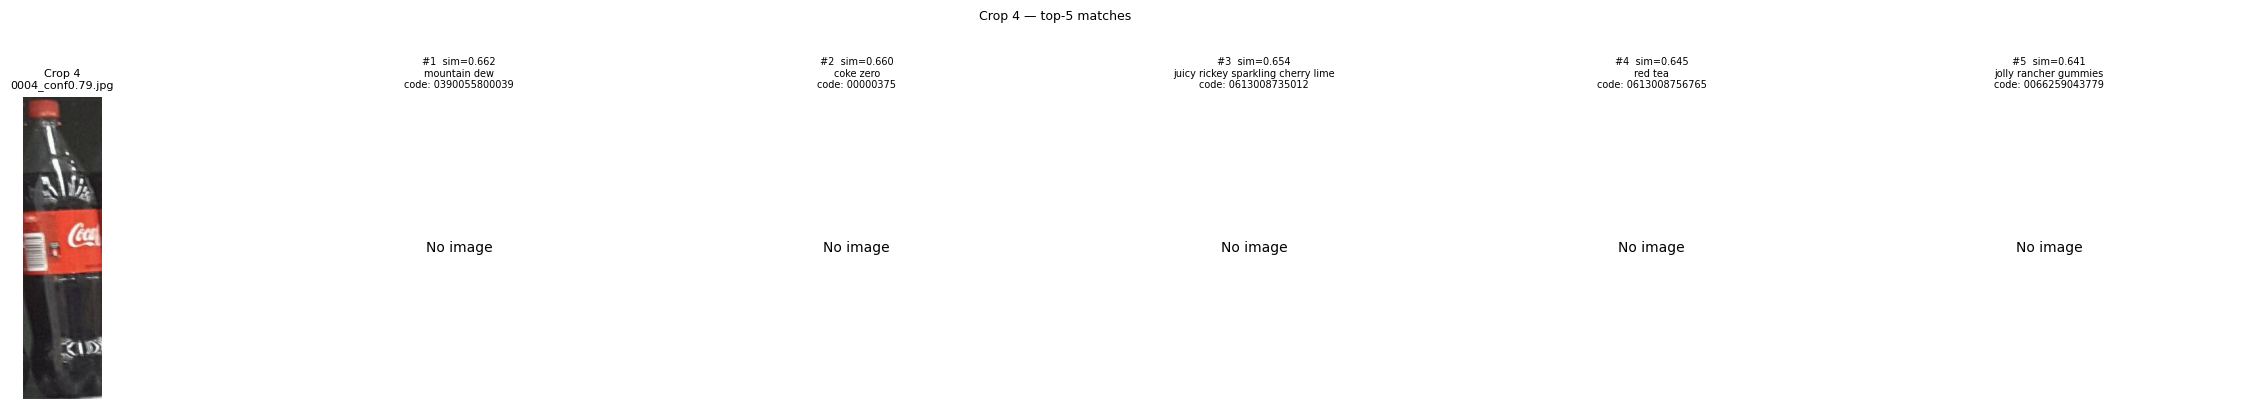


  Crop 4 best matches:
    #1  sim=0.6615  code=0390055800039  name=mountain dew
         url=https://images.openfoodfacts.org/images/products/039/005/580/0039/front_fr.3.400.jpg
    #2  sim=0.6601  code=00000375  name=coke zero
         url=https://images.openfoodfacts.org/images/products/000/000/000/0375/front_fr.16.400.jpg
    #3  sim=0.6543  code=0613008735012  name=juicy rickey sparkling cherry lime
         url=https://images.openfoodfacts.org/images/products/061/300/873/5012/front_fr.40.400.jpg
    #4  sim=0.6453  code=0613008756765  name=red tea
         url=https://images.openfoodfacts.org/images/products/061/300/875/6765/front_fr.23.400.jpg
    #5  sim=0.6406  code=0066259043779  name=jolly rancher gummies
         url=https://images.openfoodfacts.org/images/products/006/625/904/3779/front_en.23.400.jpg



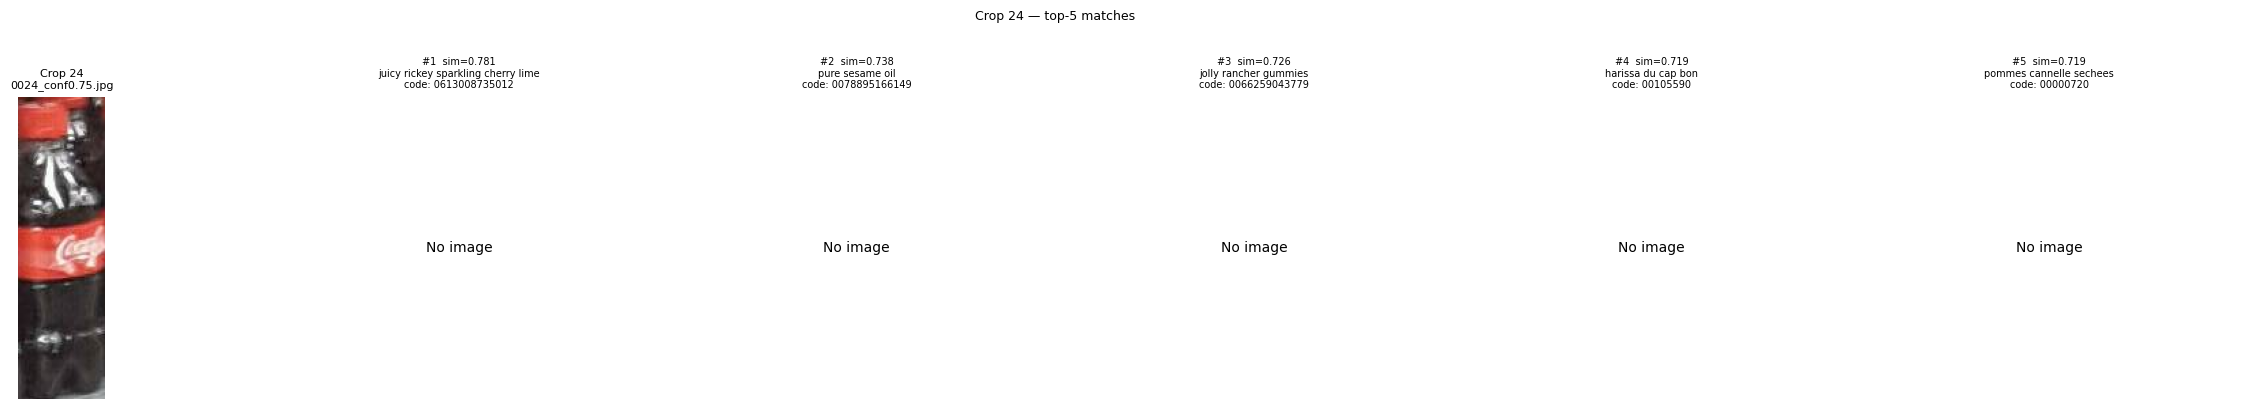


  Crop 24 best matches:
    #1  sim=0.7812  code=0613008735012  name=juicy rickey sparkling cherry lime
         url=https://images.openfoodfacts.org/images/products/061/300/873/5012/front_fr.40.400.jpg
    #2  sim=0.7379  code=0078895166149  name=pure sesame oil
         url=https://images.openfoodfacts.org/images/products/007/889/516/6149/front_en.23.400.jpg
    #3  sim=0.7257  code=0066259043779  name=jolly rancher gummies
         url=https://images.openfoodfacts.org/images/products/006/625/904/3779/front_en.23.400.jpg
    #4  sim=0.7186  code=00105590  name=harissa du cap bon
         url=https://images.openfoodfacts.org/images/products/000/000/010/5590/front_en.3.400.jpg
    #5  sim=0.7185  code=00000720  name=pommes cannelle sechees
         url=https://images.openfoodfacts.org/images/products/000/000/000/0720/front_en.17.400.jpg



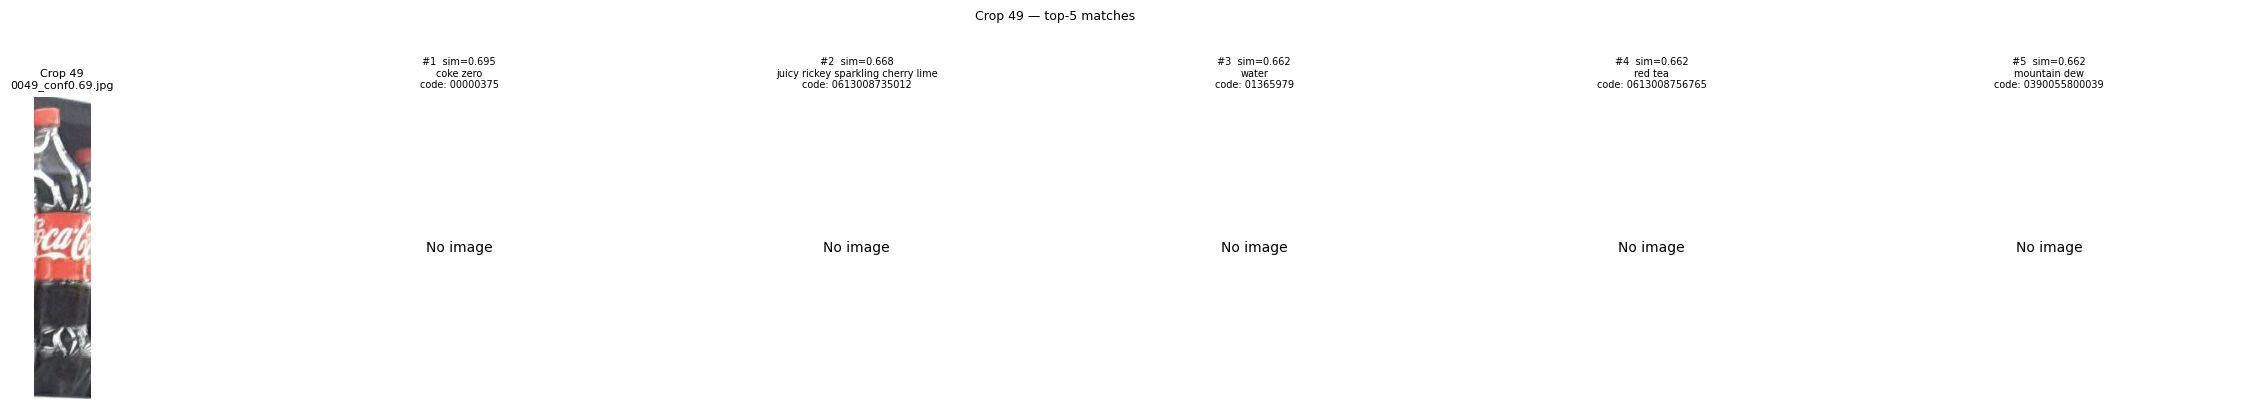


  Crop 49 best matches:
    #1  sim=0.6952  code=00000375  name=coke zero
         url=https://images.openfoodfacts.org/images/products/000/000/000/0375/front_fr.16.400.jpg
    #2  sim=0.6680  code=0613008735012  name=juicy rickey sparkling cherry lime
         url=https://images.openfoodfacts.org/images/products/061/300/873/5012/front_fr.40.400.jpg
    #3  sim=0.6622  code=01365979  name=water
         url=https://images.openfoodfacts.org/images/products/000/000/136/5979/front_fr.3.400.jpg
    #4  sim=0.6622  code=0613008756765  name=red tea
         url=https://images.openfoodfacts.org/images/products/061/300/875/6765/front_fr.23.400.jpg
    #5  sim=0.6620  code=0390055800039  name=mountain dew
         url=https://images.openfoodfacts.org/images/products/039/005/580/0039/front_fr.3.400.jpg



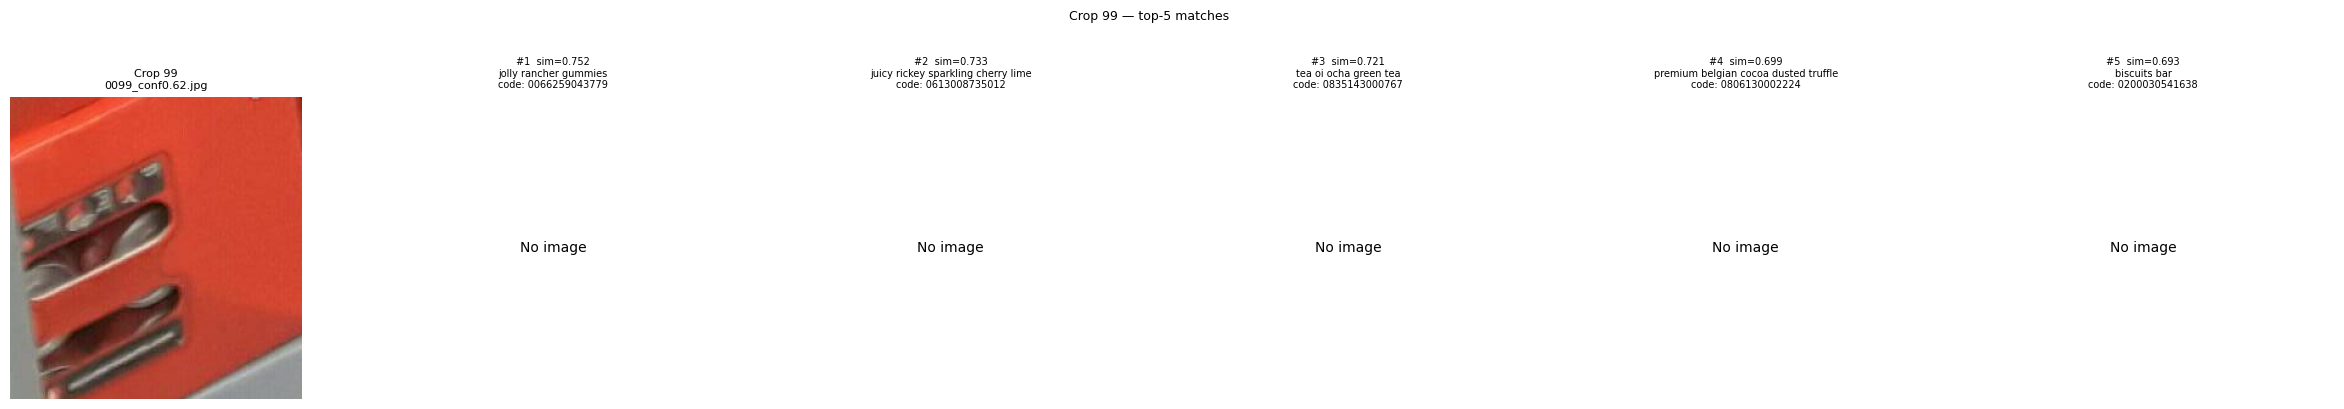


  Crop 99 best matches:
    #1  sim=0.7519  code=0066259043779  name=jolly rancher gummies
         url=https://images.openfoodfacts.org/images/products/006/625/904/3779/front_en.23.400.jpg
    #2  sim=0.7334  code=0613008735012  name=juicy rickey sparkling cherry lime
         url=https://images.openfoodfacts.org/images/products/061/300/873/5012/front_fr.40.400.jpg
    #3  sim=0.7211  code=0835143000767  name=tea oi ocha green tea
         url=https://images.openfoodfacts.org/images/products/083/514/300/0767/front_fr.16.400.jpg
    #4  sim=0.6992  code=0806130002224  name=premium belgian cocoa dusted truffle
         url=https://images.openfoodfacts.org/images/products/080/613/000/2224/front_en.3.400.jpg
    #5  sim=0.6927  code=0200030541638  name=biscuits bar
         url=https://images.openfoodfacts.org/images/products/020/003/054/1638/front_fr.15.400.jpg



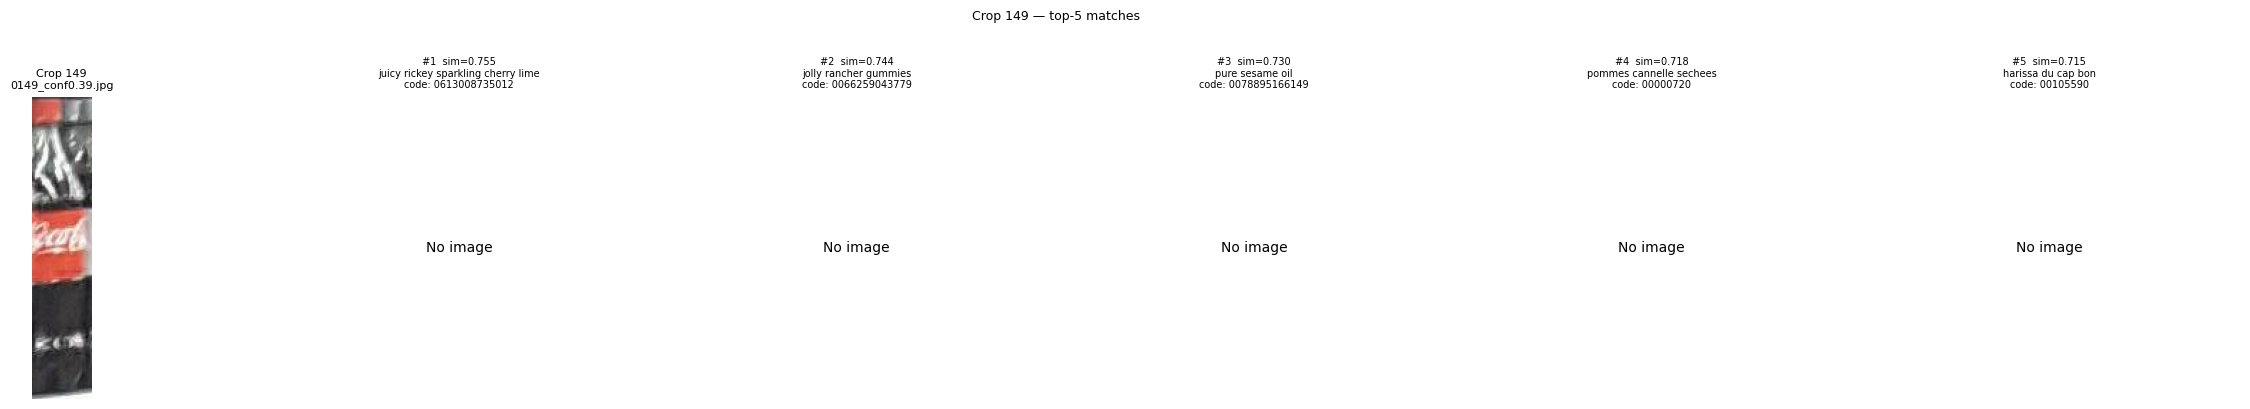


  Crop 149 best matches:
    #1  sim=0.7553  code=0613008735012  name=juicy rickey sparkling cherry lime
         url=https://images.openfoodfacts.org/images/products/061/300/873/5012/front_fr.40.400.jpg
    #2  sim=0.7442  code=0066259043779  name=jolly rancher gummies
         url=https://images.openfoodfacts.org/images/products/006/625/904/3779/front_en.23.400.jpg
    #3  sim=0.7299  code=0078895166149  name=pure sesame oil
         url=https://images.openfoodfacts.org/images/products/007/889/516/6149/front_en.23.400.jpg
    #4  sim=0.7181  code=00000720  name=pommes cannelle sechees
         url=https://images.openfoodfacts.org/images/products/000/000/000/0720/front_en.17.400.jpg
    #5  sim=0.7148  code=00105590  name=harissa du cap bon
         url=https://images.openfoodfacts.org/images/products/000/000/010/5590/front_en.3.400.jpg



In [ ]:
# # Pick 5 consistent indices spread across all results
# n_total = len(all_results)
# sample_indices = sorted(set([
#     min(4, n_total - 1),                    # ~crop 5
#     min(24, n_total - 1),                   # ~crop 25
#     min(49, n_total - 1),                   # ~crop 50
#     min(99, n_total - 1),                   # ~crop 100
#     min(149, n_total - 1),                  # ~crop 150
# ]))
# print(f"Showing crops: {sample_indices} (out of {n_total} total)")

# for crop_idx in sample_indices:
#     crop_pil, crop_path, matches = all_results[crop_idx]
#     n_matches = len(matches)
#     fig, axes = plt.subplots(1, 1 + n_matches, figsize=(4 * (1 + n_matches), 4))
#     if n_matches == 0:
#         axes = [axes]

#     axes[0].imshow(crop_pil)
#     axes[0].set_title(f"Crop {crop_idx}\n{crop_path.name}", fontsize=8)
#     axes[0].axis("off")

#     for rank, (ax, m) in enumerate(zip(axes[1:], matches), start=1):
#         match_img = fetch_pil(m["image_url"]) if m["image_url"] else None
#         if match_img:
#             ax.imshow(match_img)
#         else:
#             ax.text(0.5, 0.5, "No image", ha="center", va="center", transform=ax.transAxes)

#         title = (
#             f"#{rank}  sim={m['similarity']:.3f}\n"
#             f"{m['product_name']}\n"
#             f"code: {m['code']}"
#         )
#         ax.set_title(title, fontsize=7)
#         ax.axis("off")

#     plt.suptitle(f"Crop {crop_idx} — top-{n_matches} matches", fontsize=9, y=1.01)
#     plt.tight_layout()
#     plt.savefig(run_dir / f"{crop_idx:04d}_matches.png", bbox_inches="tight", dpi=120)
#     plt.show()
#     print()

#     print(f"  Crop {crop_idx} best matches:")
#     for rank, m in enumerate(matches, 1):
#         print(f"    #{rank}  sim={m['similarity']:.4f}  "
#               f"code={m['code']}  name={m['product_name']}")
#         print(f"         url={m['image_url']}")
#     print()

In [38]:
display(m)

{'similarity': 0.7302693724632263,
 'code': '54491472',
 'product_name': 'original ethiopian',
 'image_url': 'https://images.openfoodfacts.org/images/products/000/005/449/1472/front_de.400.400.jpg'}

Showing crops: [4, 9, 14, 34, 146] (out of 188 total)


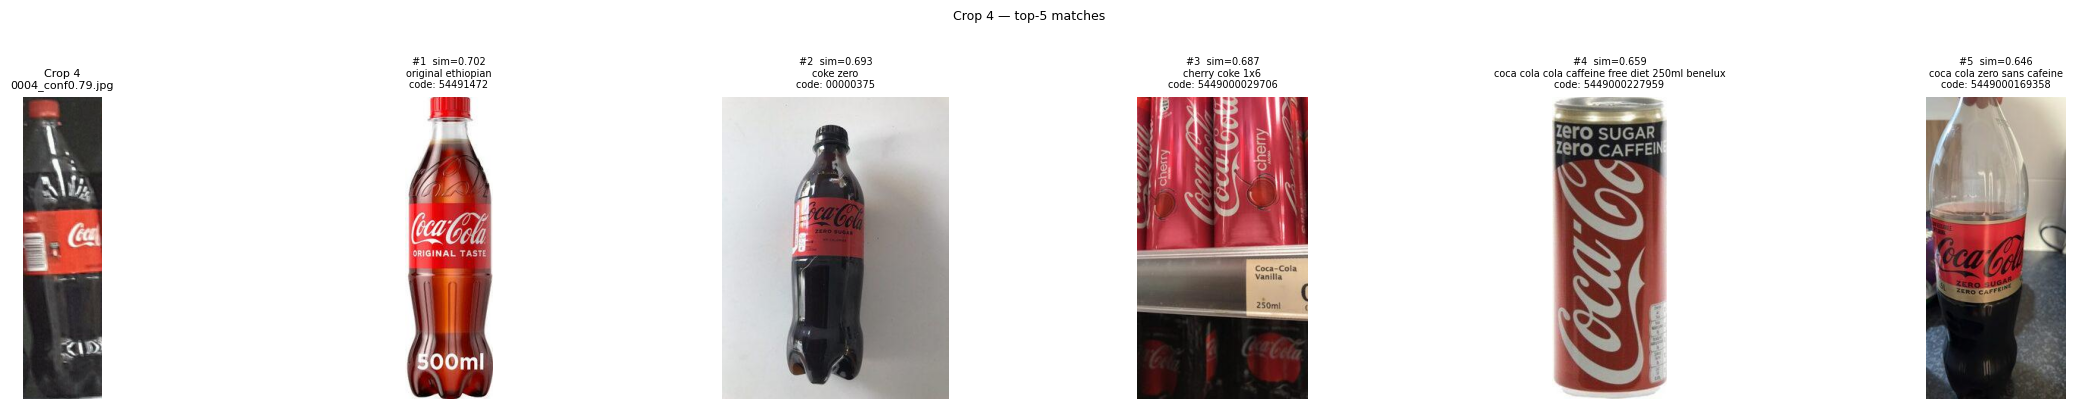


  Crop 4 best matches:
    #1  sim=0.7022  code=54491472  name=original ethiopian
         url=https://images.openfoodfacts.org/images/products/000/005/449/1472/front_de.400.400.jpg
    #2  sim=0.6931  code=00000375  name=coke zero
         url=https://images.openfoodfacts.org/images/products/000/000/000/0375/front_fr.16.400.jpg
    #3  sim=0.6872  code=5449000029706  name=cherry coke 1x6
         url=https://images.openfoodfacts.org/images/products/544/900/002/9706/front_fr.9.400.jpg
    #4  sim=0.6593  code=5449000227959  name=coca cola cola caffeine free diet 250ml benelux
         url=https://images.openfoodfacts.org/images/products/544/900/022/7959/front_fr.18.400.jpg
    #5  sim=0.6462  code=5449000169358  name=coca cola zero sans cafeine
         url=https://images.openfoodfacts.org/images/products/544/900/016/9358/front_fr.37.400.jpg



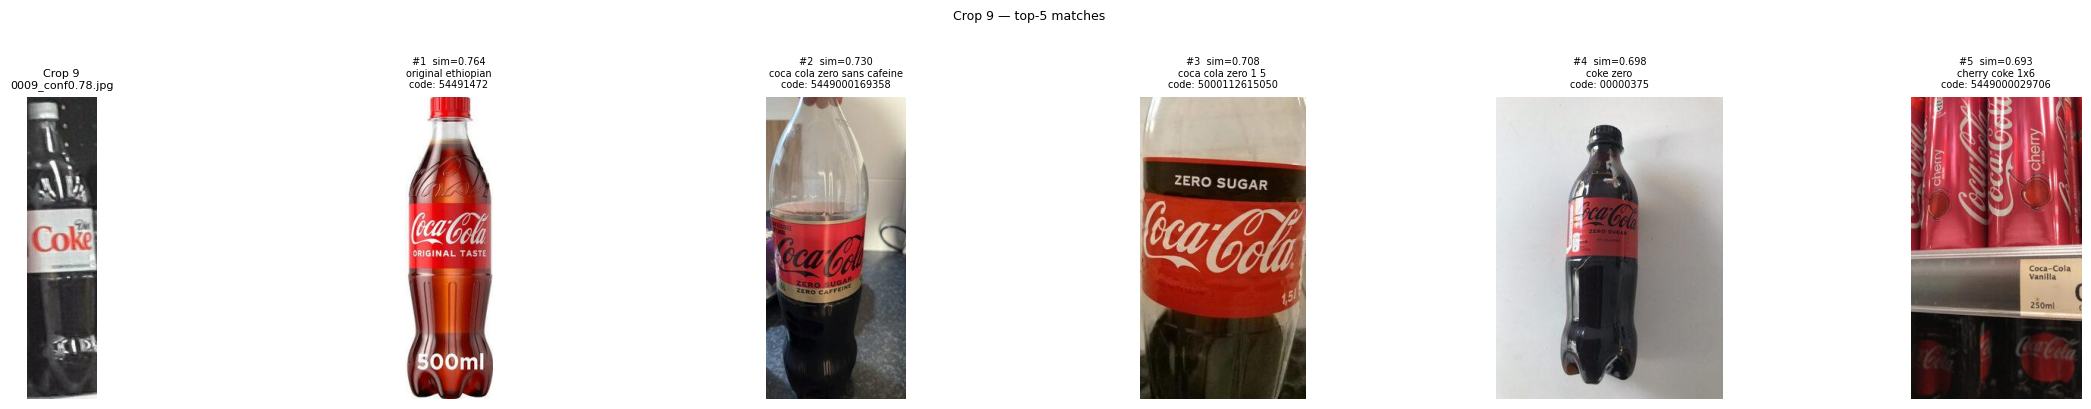


  Crop 9 best matches:
    #1  sim=0.7640  code=54491472  name=original ethiopian
         url=https://images.openfoodfacts.org/images/products/000/005/449/1472/front_de.400.400.jpg
    #2  sim=0.7299  code=5449000169358  name=coca cola zero sans cafeine
         url=https://images.openfoodfacts.org/images/products/544/900/016/9358/front_fr.37.400.jpg
    #3  sim=0.7081  code=5000112615050  name=coca cola zero 1 5
         url=https://images.openfoodfacts.org/images/products/500/011/261/5050/front_fr.3.400.jpg
    #4  sim=0.6983  code=00000375  name=coke zero
         url=https://images.openfoodfacts.org/images/products/000/000/000/0375/front_fr.16.400.jpg
    #5  sim=0.6931  code=5449000029706  name=cherry coke 1x6
         url=https://images.openfoodfacts.org/images/products/544/900/002/9706/front_fr.9.400.jpg



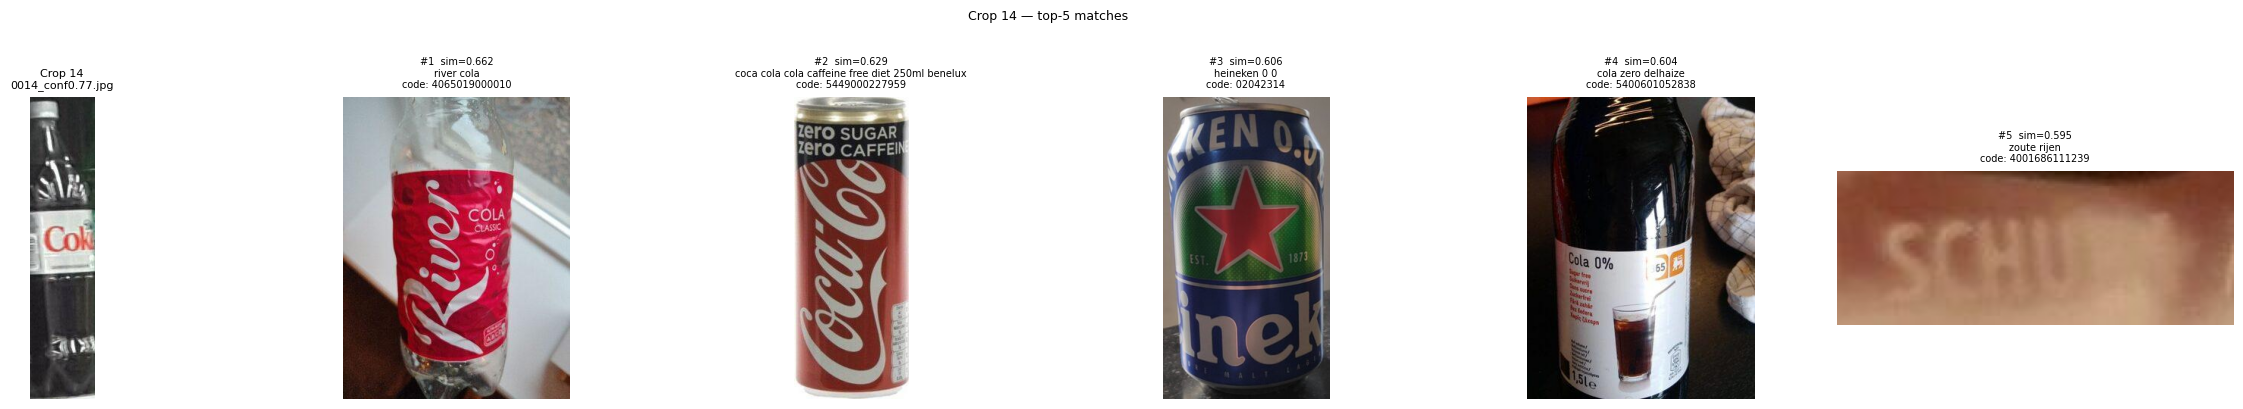


  Crop 14 best matches:
    #1  sim=0.6617  code=4065019000010  name=river cola
         url=https://images.openfoodfacts.org/images/products/406/501/900/0010/front_fr.7.400.jpg
    #2  sim=0.6285  code=5449000227959  name=coca cola cola caffeine free diet 250ml benelux
         url=https://images.openfoodfacts.org/images/products/544/900/022/7959/front_fr.18.400.jpg
    #3  sim=0.6061  code=02042314  name=heineken 0 0
         url=https://images.openfoodfacts.org/images/products/000/000/204/2314/front_fr.4.400.jpg
    #4  sim=0.6039  code=5400601052838  name=cola zero delhaize
         url=https://images.openfoodfacts.org/images/products/540/060/105/2838/front_fr.9.400.jpg
    #5  sim=0.5953  code=4001686111239  name=zoute rijen
         url=https://images.openfoodfacts.org/images/products/400/168/611/1239/front_nl.9.400.jpg



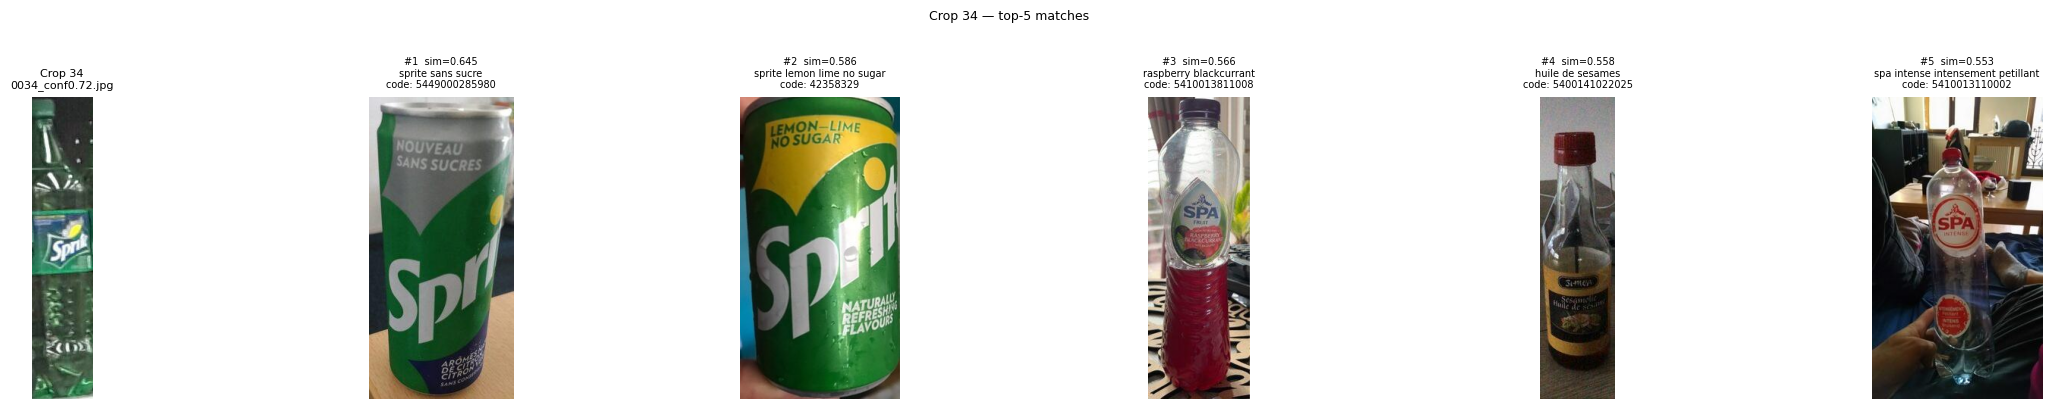


  Crop 34 best matches:
    #1  sim=0.6451  code=5449000285980  name=sprite sans sucre
         url=https://images.openfoodfacts.org/images/products/544/900/028/5980/front_fr.26.400.jpg
    #2  sim=0.5863  code=42358329  name=sprite lemon lime no sugar
         url=https://images.openfoodfacts.org/images/products/000/004/235/8329/front_fr.3.400.jpg
    #3  sim=0.5658  code=5410013811008  name=raspberry blackcurrant
         url=https://images.openfoodfacts.org/images/products/541/001/381/1008/front_fr.3.400.jpg
    #4  sim=0.5579  code=5400141022025  name=huile de sesames
         url=https://images.openfoodfacts.org/images/products/540/014/102/2025/front_fr.14.400.jpg
    #5  sim=0.5531  code=5410013110002  name=spa intense intensement petillant
         url=https://images.openfoodfacts.org/images/products/541/001/311/0002/front_fr.7.400.jpg



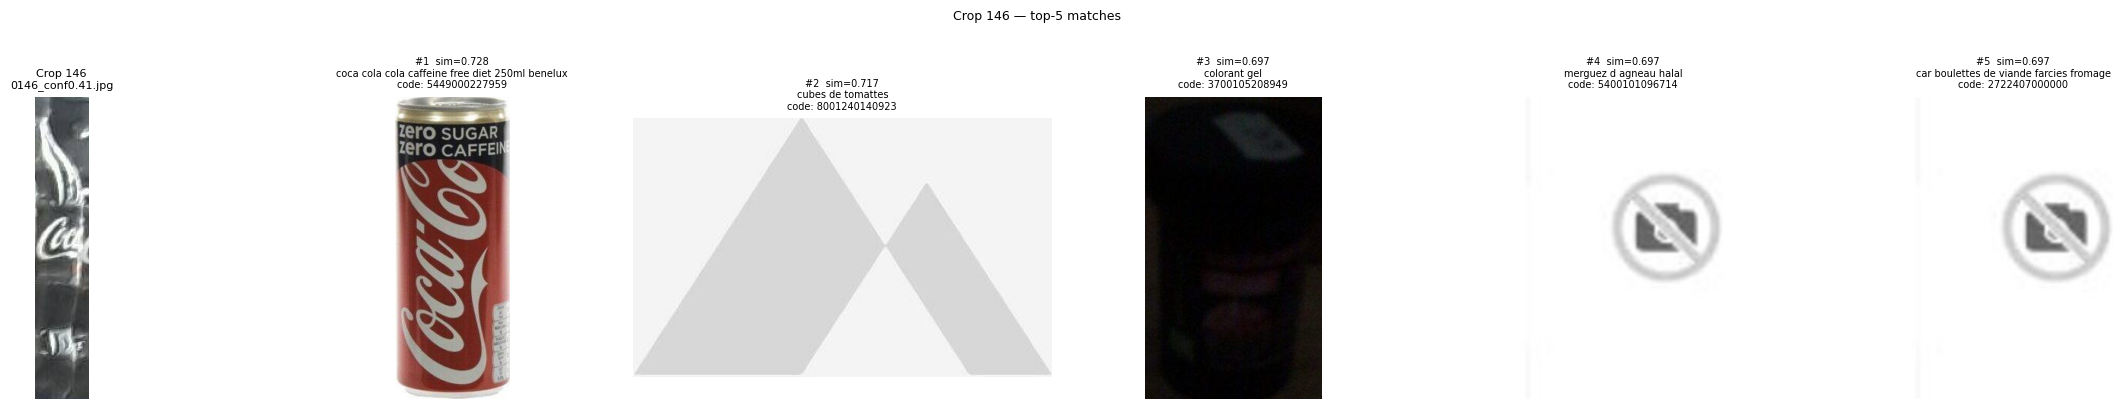


  Crop 146 best matches:
    #1  sim=0.7282  code=5449000227959  name=coca cola cola caffeine free diet 250ml benelux
         url=https://images.openfoodfacts.org/images/products/544/900/022/7959/front_fr.18.400.jpg
    #2  sim=0.7168  code=8001240140923  name=cubes de tomattes
         url=https://images.openfoodfacts.org/images/products/800/124/014/0923/front_en.16.400.jpg
    #3  sim=0.6972  code=3700105208949  name=colorant gel
         url=https://images.openfoodfacts.org/images/products/370/010/520/8949/front_fr.11.400.jpg
    #4  sim=0.6966  code=5400101096714  name=merguez d agneau halal
         url=https://images.openfoodfacts.org/images/products/540/010/109/6714/front_fr.5.400.jpg
    #5  sim=0.6966  code=2722407000000  name=car boulettes de viande farcies fromage
         url=https://images.openfoodfacts.org/images/products/272/240/700/0000/front_fr.5.400.jpg



In [9]:
# Pick 5 consistent indices spread across all results
n_total = len(all_results)
sample_indices = sorted(set([
    min(4, n_total - 1),                   
    min(9, n_total - 1),                   
    min(14, n_total - 1),                   
    min(34, n_total - 1),                   
    min(146, n_total - 1),                 
]))
print(f"Showing crops: {sample_indices} (out of {n_total} total)")

for crop_idx in sample_indices:
    crop_pil, crop_path, matches = all_results[crop_idx]
    n_matches = len(matches)
    fig, axes = plt.subplots(1, 1 + n_matches, figsize=(4 * (1 + n_matches), 4))
    if n_matches == 0:
        axes = [axes]

    axes[0].imshow(crop_pil)
    axes[0].set_title(f"Crop {crop_idx}\n{crop_path.name}", fontsize=8)
    axes[0].axis("off")

    for rank, (ax, m) in enumerate(zip(axes[1:], matches), start=1):

      code = str(m["code"]).replace("/", "_")
      filename = Path(m["image_url"]).name
      image_key = filename.split(".")[0]

      match_img = load_local_pil(code, image_key)

      if match_img:
          ax.imshow(match_img)
      else:
          ax.text(
              0.5,
              0.5,
              "No image",
              ha="center",
              va="center",
              transform=ax.transAxes
          )

      title = (
          f"#{rank}  sim={m['similarity']:.3f}\n"
          f"{m['product_name']}\n"
          f"code: {m['code']}"
      )

      ax.set_title(title, fontsize=7)
      ax.axis("off")

    plt.suptitle(f"Crop {crop_idx} — top-{n_matches} matches", fontsize=9, y=1.01)
    plt.tight_layout()
    plt.savefig(run_dir / f"{crop_idx:04d}_matches.png", bbox_inches="tight", dpi=120)
    plt.show()
    print()

    print(f"  Crop {crop_idx} best matches:")
    for rank, m in enumerate(matches, 1):
        print(f"    #{rank}  sim={m['similarity']:.4f}  "
              f"code={m['code']}  name={m['product_name']}")
        print(f"         url={m['image_url']}")
    print()

In [17]:
# Check what a freshly embedded dataset image looks like vs a cached one
query_img = fetch_pil("https://images.openfoodfacts.org/images/products/544/900/005/4227/front_en.406.400.jpg")

fresh_vec = fused_embed(query_img)

cache_file = Path("./faiss_progress") / f"row_{398:07d}.npy"  # first coke entry
cached_vec = np.load(str(cache_file))

print(f"Fresh vec  — first 512 (CLIP):  mean={fresh_vec[:512].mean():.4f}  std={fresh_vec[:512].std():.4f}")
print(f"Fresh vec  — next 512 (OCR):    mean={fresh_vec[512:1024].mean():.4f}  std={fresh_vec[512:1024].std():.4f}")
print()
print(f"Cached vec — first 512 (CLIP):  mean={cached_vec[:512].mean():.4f}  std={cached_vec[:512].std():.4f}")
print(f"Cached vec — next 512 (OCR):    mean={cached_vec[512:1024].mean():.4f}  std={cached_vec[512:1024].std():.4f}")


Fresh vec  — first 512 (CLIP):  mean=0.0009  std=0.0342
Fresh vec  — next 512 (OCR):    mean=0.0024  std=0.0279

Cached vec — first 512 (CLIP):  mean=-0.0008  std=0.0341
Cached vec — next 512 (OCR):    mean=0.0014  std=0.0272


In [33]:
test_crop_pil = all_results[0][0]

# Dit test voor clip 70%, 50% en 30%, idem voor Florence-2
for cw, fw in [(0.7, 0.3), (0.5, 0.5), (0.3, 0.7), 
               (0.45, 0.55), (0.425, 0.575), (0.475, 0.525)
               ,(0.525, 0.475), (0.55, 0.45), (0.575, 0.425)]:
    orig_c, orig_f = CLIP_WEIGHT, OCR_WEIGHT
    CLIP_WEIGHT, OCR_WEIGHT = cw, fw

    top1 = search(test_crop_pil, k=1)
    m    = top1[0] if top1 else {}
    print(f"CLIP={cw} / FL2={fw}  →  {m.get('product_name')}  sim={m.get('similarity', 0):.4f}")

    CLIP_WEIGHT, OCR_WEIGHT = orig_c, orig_f

CLIP=0.7 / FL2=0.3  →  Coca-Cola  sim=0.8424
CLIP=0.5 / FL2=0.5  →  Coca-Cola  sim=0.8902
CLIP=0.3 / FL2=0.7  →  Coca light 1.5l  sim=0.8153
CLIP=0.45 / FL2=0.55  →  Coca-Cola  sim=0.8815
CLIP=0.425 / FL2=0.575  →  Coca-Cola  sim=0.8740
CLIP=0.475 / FL2=0.525  →  Coca-Cola  sim=0.8869
CLIP=0.525 / FL2=0.475  →  Coca-Cola  sim=0.8912
CLIP=0.55 / FL2=0.45  →  Coca-Cola  sim=0.8900
CLIP=0.575 / FL2=0.425  →  Coca-Cola  sim=0.8867


In [ ]:
# Build a controlled test: pick 10 specific products, index them,
# then query with their own image and see if top-1 is correct
test_products = meta_df.sample(10, seed=42)

correct = 0
for row in test_products.iter_rows(named=True):
    img = fetch_pil(row["image_url"])
    if img is None:
        continue
    matches = search(img, k=1)
    top1_code = matches[0]["code"] if matches else None
    hit = top1_code == row["code"]
    correct += hit
    print(f"{'✓' if hit else '✗'}  {row['product_name'][:40]}  → matched: {matches[0]['product_name'][:40]}  sim={matches[0]['similarity']:.4f}")

print(f"\nTop-1 accuracy: {correct}/{len(test_products)}")

In [42]:
def search_weighted(pil_image: Image.Image, cw: float, ow: float, fw: float, k: int = TOP_K):
    """Search with explicit per-model weights without mutating globals."""
    clip_img = clip_embed(pil_image)
    ocr_vec  = fl2_ocr_embed(pil_image)
    fl2_vis  = fl2_embed(pil_image)

    fused = np.concatenate([
        cw * clip_img,
        ow * ocr_vec,
        fw * fl2_vis,
    ])
    norm  = np.linalg.norm(fused) + 1e-9
    vec   = (fused / norm).reshape(1, -1).astype("float32")

    scores, idxs = index.search(vec, k)
    matches = []
    for score, idx in zip(scores[0], idxs[0]):
        if idx == -1:
            continue
        row = meta_df.row(idx, named=True)
        matches.append({
            "similarity"   : float(score),
            "code"         : row.get("code"),
            "product_name" : row.get("product_name"),
            "image_url"    : row.get("image_url") or row.get("url"),
        })
    return matches

In [ ]:
test_crop_pil = all_results[0][0]

experiments = [
    # label,                    clip,  ocr,   fl2_vis
    # ── Gelijkmatig ──────────────────────────────────
    ("Equal (0.33/0.33/0.33)",  0.33,  0.33,  0.33),

    # ── CLIP dominant ────────────────────────────────
    ("CLIP 0.70 / OCR 0.20 / FL2 0.10", 0.70, 0.20, 0.10),
    ("CLIP 0.60 / OCR 0.25 / FL2 0.15", 0.60, 0.25, 0.15),
    ("CLIP 0.50 / OCR 0.30 / FL2 0.20", 0.50, 0.30, 0.20),

    # ── OCR dominant ─────────────────────────────────
    ("OCR 0.70 / CLIP 0.20 / FL2 0.10",  0.20, 0.70, 0.10),
    ("OCR 0.60 / CLIP 0.25 / FL2 0.15",  0.25, 0.60, 0.15),
    ("OCR 0.50 / CLIP 0.30 / FL2 0.20",  0.30, 0.50, 0.20),

    # ── FL2-visual dominant ───────────────────────────
    ("FL2 0.70 / CLIP 0.20 / OCR 0.10",  0.20, 0.10, 0.70),
    ("FL2 0.60 / CLIP 0.25 / OCR 0.15",  0.25, 0.15, 0.60),
    ("FL2 0.50 / CLIP 0.30 / OCR 0.20",  0.30, 0.20, 0.50),

    # ── Fijnafstemming: CLIP + OCR, vorige config ────
    ("CLIP 0.55 / OCR 0.45 / FL2 0.00",  0.55, 0.45, 0.00),
    ("CLIP 0.45 / OCR 0.55 / FL2 0.00",  0.45, 0.55, 0.00),
    ("CLIP 0.50 / OCR 0.50 / FL2 0.00",  0.50, 0.50, 0.00),

    # ── Fijnafstemming: CLIP + FL2 ───────────────────
    ("CLIP 0.55 / FL2 0.45 / OCR 0.00",  0.55, 0.00, 0.45),
    ("CLIP 0.50 / FL2 0.50 / OCR 0.00",  0.50, 0.00, 0.50),
    ("CLIP 0.60 / FL2 0.40 / OCR 0.00",  0.60, 0.00, 0.40),

    # ── Fijnafstemming: OCR + FL2 ────────────────────
    ("OCR 0.55 / FL2 0.45 / CLIP 0.00",  0.00, 0.55, 0.45),
    ("OCR 0.50 / FL2 0.50 / CLIP 0.00",  0.00, 0.50, 0.50),
    ("OCR 0.45 / FL2 0.55 / CLIP 0.00",  0.00, 0.45, 0.55),

    # ── Ablaties: elk model volledig weggelaten ───────
    ("Alleen CLIP (OCR=0, FL2=0)",        1.00, 0.00, 0.00),
    ("Alleen OCR  (CLIP=0, FL2=0)",       0.00, 1.00, 0.00),
    ("Alleen FL2  (CLIP=0, OCR=0)",       0.00, 0.00, 1.00),
]

rows = []
print(f"{'#':>3}  {'CLIP':>5}  {'OCR':>5}  {'FL2':>5}  {'Sim':>7}  Product")
print("─" * 80)

for i, (label, cw, ow, fw) in enumerate(experiments, 1):
    top1 = search_weighted(test_crop_pil, cw=cw, ow=ow, fw=fw, k=1)
    m    = top1[0] if top1 else {}
    sim  = m.get("similarity", 0.0)
    name = (m.get("product_name") or "—")[:40]
    rows.append((label, cw, ow, fw, sim, name))
    print(f"{i:>3}  {cw:>5.2f}  {ow:>5.2f}  {fw:>5.2f}  {sim:>7.4f}  {name}")

# ── Samenvatting: beste configuratie ─────────────────────────────────────────
best = max(rows, key=lambda r: r[4])
print("\n" + "═" * 80)
print(f"Beste configuratie : {best[0]}")
print(f"  CLIP={best[1]:.2f}  OCR={best[2]:.2f}  FL2={best[3]:.2f}  sim={best[4]:.4f}")
print(f"  Match            : {best[5]}")

  #   CLIP    OCR    FL2      Sim  Product
────────────────────────────────────────────────────────────────────────────────
  1   0.33   0.33   0.33   0.7362  original ethiopian
  2   0.70   0.20   0.10   0.7878  original ethiopian
  3   0.60   0.25   0.15   0.8118  original ethiopian
  4   0.50   0.30   0.20   0.8179  original ethiopian
  5   0.20   0.70   0.10   0.7059  12 mini babybel
  6   0.25   0.60   0.15   0.7221  12 mini babybel
  7   0.30   0.50   0.20   0.7516  original ethiopian
  8   0.20   0.10   0.70   0.3725  original ethiopian
  9   0.25   0.15   0.60   0.4764  original ethiopian
 10   0.30   0.20   0.50   0.5870  original ethiopian
 11   0.55   0.45   0.00   0.8191  original ethiopian
 12   0.45   0.55   0.00   0.7904  original ethiopian
 13   0.50   0.50   0.00   0.8088  original ethiopian
 14   0.55   0.00   0.45   0.6049  original ethiopian
 15   0.50   0.00   0.50   0.5695  original ethiopian
 16   0.60   0.00   0.40   0.6337  original ethiopian
 17   0.00   0.55 